# 04 · Descriptive analysis

Plots 1–9 from the brief. COVID is shaded on every time-series panel
(`2020-03…2021-12` hard hole = dark band, `2022` degraded recovery = light band).
Nominal series use the **full 2008– history**; anything CPI-deflated is
restricted to the **2016-12 → 2026-05** analysis window.

**Input** `data/processed/03_analysis_panel.parquet` →
**Output** `outputs/figures/04_plotN_*.png`, `outputs/tables/table1_descriptives.csv`
(refreshed with the full descriptive set).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("04_descriptive")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
W = df[df.in_window == 1].copy()
MODEL = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
COVID_HOLE = (pd.Timestamp(C.COVID_HOLE_START), pd.Timestamp(C.COVID_HOLE_END))
COVID_REC = (pd.Timestamp(C.COVID_RECOVERY_START), pd.Timestamp(C.COVID_RECOVERY_END))


def shade_covid(ax):
    ax.axvspan(*COVID_HOLE, color="0.55", alpha=.30, lw=0, zorder=0)
    ax.axvspan(*COVID_REC, color="0.75", alpha=.25, lw=0, zorder=0)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(C.OUT_FIG / name)
    LOG.log("figure", name)
    plt.show()

## Plot 1 · Nominal average rate over time, by category (full history, log scale)

  [04_descriptive] figure                 04_plot1_nominal_rate.png                  


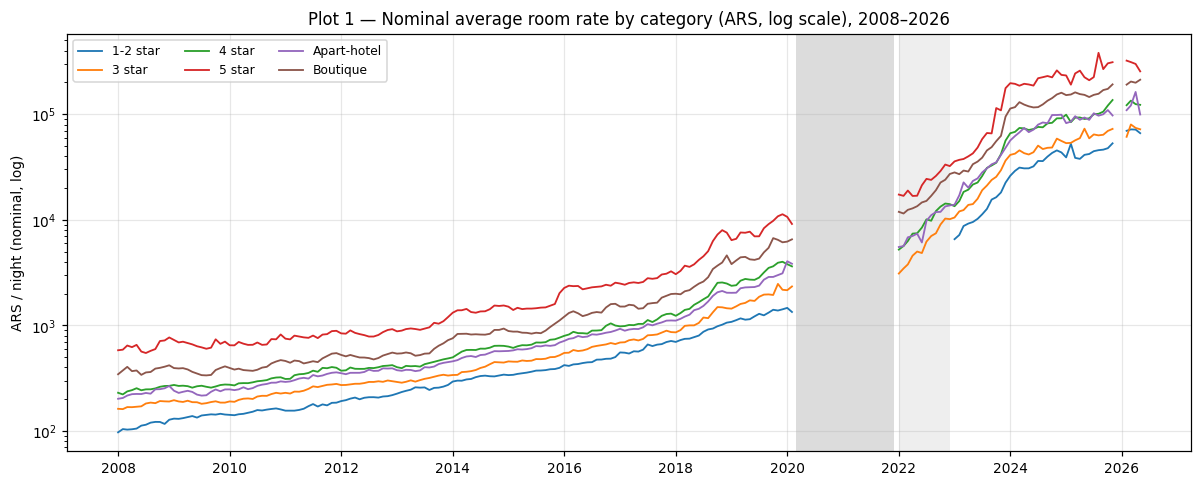

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cat in MODEL:
    s = df[df.hotel_category == cat].sort_values("date")
    ax.plot(s.date, s.average_rate, lw=1.2, label=LAB[cat])
shade_covid(ax)
ax.set_yscale("log")
ax.set_title("Plot 1 — Nominal average room rate by category (ARS, log scale), 2008–2026")
ax.set_ylabel("ARS / night (nominal, log)")
ax.legend(ncol=3, fontsize=8)
save(fig, "04_plot1_nominal_rate.png")

## Plot 2 · Real average rate over time, by category (analysis window, dic-2016 pesos)

  [04_descriptive] figure                 04_plot2_real_rate.png                     


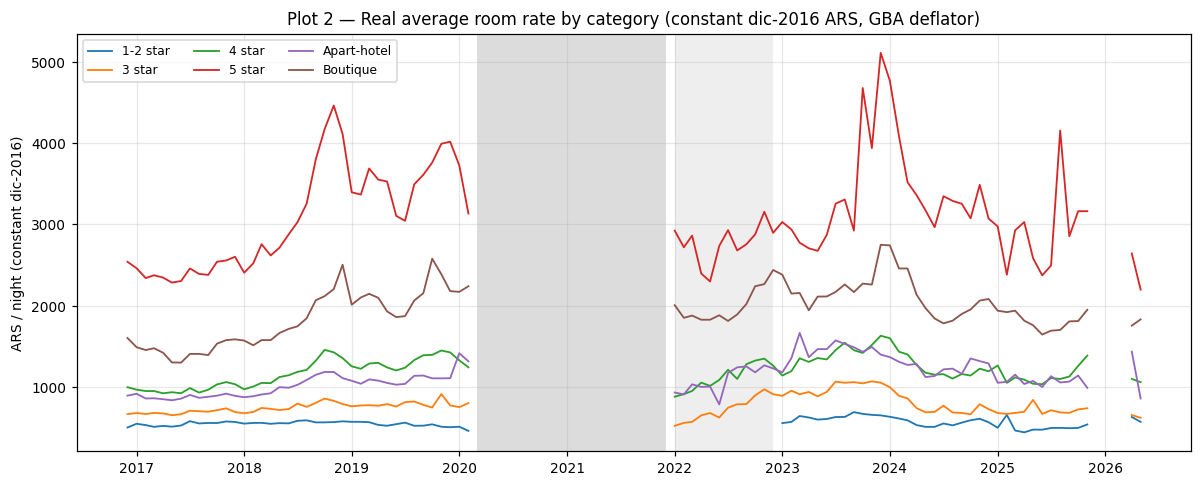

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cat in MODEL:
    s = W[W.hotel_category == cat].sort_values("date")
    ax.plot(s.date, s.real_rate_gba, lw=1.2, label=LAB[cat])
shade_covid(ax)
ax.set_title("Plot 2 — Real average room rate by category (constant dic-2016 ARS, GBA deflator)")
ax.set_ylabel("ARS / night (constant dic-2016)")
ax.legend(ncol=3, fontsize=8)
save(fig, "04_plot2_real_rate.png")

## Plot 3 · Hotel-rate inflation vs CPI inflation

Category rate MoM growth (median across the 4 star tiers, with IQR band) against
GBA headline CPI MoM and the `Restaurantes y hoteles` CPI division MoM.

  [04_descriptive] figure                 04_plot3_rate_vs_cpi_inflation.png           


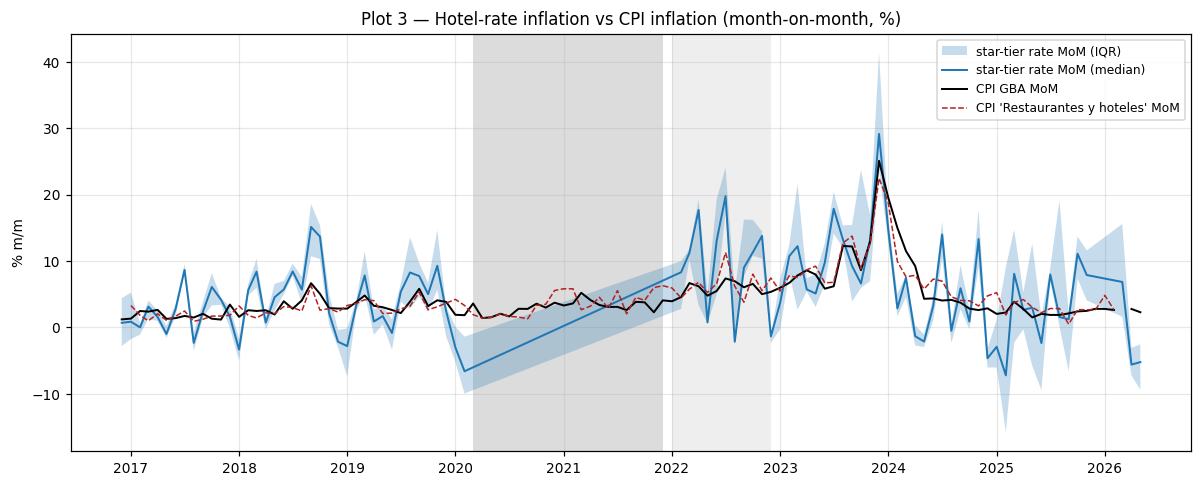

In [4]:
g = (W[W.hotel_category.isin(C.CORE_CATEGORIES)]
     .pivot_table(index="date", columns="hotel_category", values="dln_average_rate"))
rate_mom = (np.exp(g) - 1) * 100
cpi_mom = W.groupby("date")[["infl_mom_gba"]].first()
rh_mom = W.groupby("date")["cpi_resthot_gba"].first().pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(rate_mom.index, rate_mom.quantile(.25, axis=1),
                rate_mom.quantile(.75, axis=1), alpha=.25, label="star-tier rate MoM (IQR)")
ax.plot(rate_mom.index, rate_mom.median(axis=1), lw=1.3, label="star-tier rate MoM (median)")
ax.plot(cpi_mom.index, cpi_mom.infl_mom_gba, lw=1.3, color="k", label="CPI GBA MoM")
ax.plot(rh_mom.index, rh_mom, lw=1.0, ls="--", color="firebrick",
        label="CPI 'Restaurantes y hoteles' MoM")
shade_covid(ax)
ax.set_title("Plot 3 — Hotel-rate inflation vs CPI inflation (month-on-month, %)")
ax.set_ylabel("% m/m")
ax.legend(fontsize=8)
save(fig, "04_plot3_rate_vs_cpi_inflation.png")

## Plot 4 · Room occupancy over time, by category

  [04_descriptive] figure                 04_plot4_room_occupancy.png                


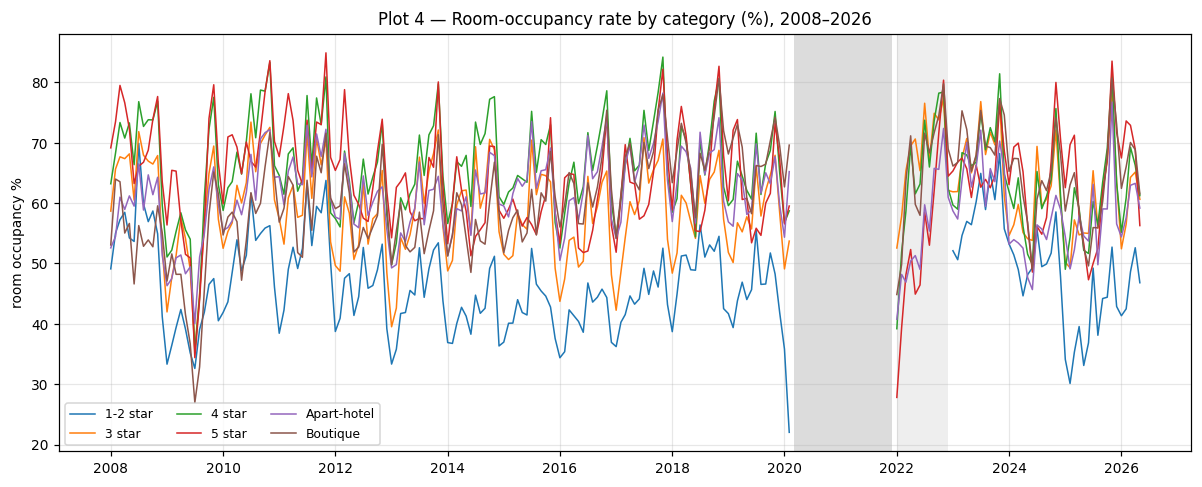

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cat in MODEL:
    s = df[df.hotel_category == cat].sort_values("date")
    ax.plot(s.date, s.room_occupancy, lw=1.0, label=LAB[cat])
shade_covid(ax)
ax.set_title("Plot 4 — Room-occupancy rate by category (%), 2008–2026")
ax.set_ylabel("room occupancy %")
ax.legend(ncol=3, fontsize=8)
save(fig, "04_plot4_room_occupancy.png")

## Plot 5 · Rate growth vs occupancy growth (Δln, in-window, COVID-excluded)

  [04_descriptive] figure                 04_plot5_rate_vs_occ_growth.png            


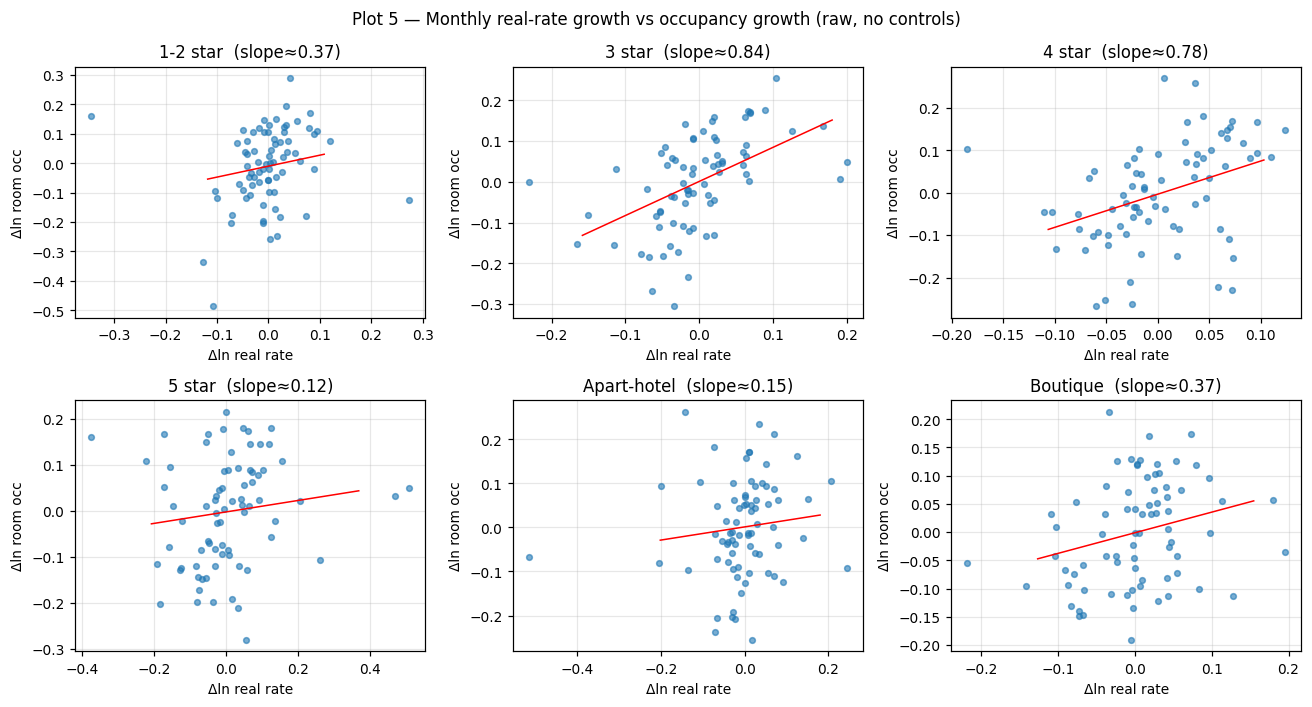

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, cat in zip(axes.ravel(), MODEL):
    s = W[(W.hotel_category == cat) & (W.covid_any == 0)]
    ax.scatter(s.dln_real_rate_gba, s.dln_room_occupancy, s=14, alpha=.6)
    b, a = np.polyfit(s.dln_real_rate_gba.dropna(),
                      s.loc[s.dln_real_rate_gba.notna(), "dln_room_occupancy"], 1) \
        if s.dln_real_rate_gba.notna().sum() > 5 else (np.nan, np.nan)
    xs = np.linspace(*np.nanpercentile(s.dln_real_rate_gba, [2, 98]), 20)
    ax.plot(xs, a + b * xs, "r-", lw=1)
    ax.set_title(f"{LAB[cat]}  (slope≈{b:0.2f})")
    ax.set_xlabel("Δln real rate"); ax.set_ylabel("Δln room occ")
fig.suptitle("Plot 5 — Monthly real-rate growth vs occupancy growth (raw, no controls)")
save(fig, "04_plot5_rate_vs_occ_growth.png")

## Plot 6 · Inflation vs hotel price-adjustment magnitude

These are reported **average** rates, so they move almost every month; the
informative margin is the *size* and *dispersion* of the monthly change, not a
menu-cost "frequency". Binned by CPI-MoM regime.

  [04_descriptive] figure                 04_plot6_inflation_vs_adjustment.png           


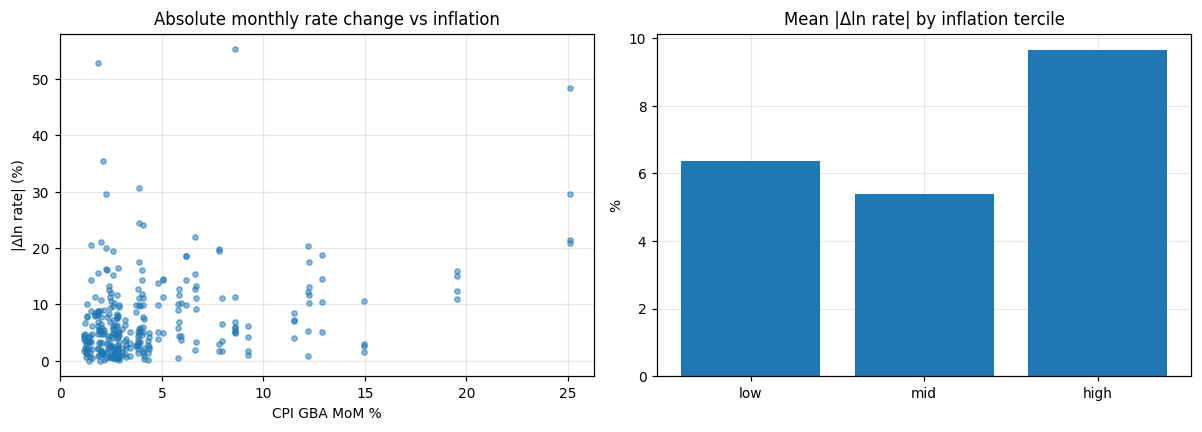

,cpi_mom_mean,mean_abs_dln_pct,sd_dln_pct,share_up
reg,,,,
low,1.86,6.38,9.65,0.65
mid,3.06,5.39,7.21,0.61
high,8.56,9.65,9.56,0.83


In [7]:
s = W[(W.hotel_category.isin(C.CORE_CATEGORIES)) & (W.covid_any == 0)].copy()
s["abs_dln"] = s.dln_average_rate.abs()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(s.infl_mom_gba, s.abs_dln * 100, s=12, alpha=.5)
ax[0].set_xlabel("CPI GBA MoM %"); ax[0].set_ylabel("|Δln rate| (%)")
ax[0].set_title("Absolute monthly rate change vs inflation")
q = pd.qcut(s.infl_mom_gba, 3, labels=["low", "mid", "high"])
bx = s.assign(reg=q).groupby("reg", observed=True)
tab = bx.agg(cpi_mom_mean=("infl_mom_gba", "mean"),
             mean_abs_dln_pct=("abs_dln", lambda x: x.mean() * 100),
             sd_dln_pct=("dln_average_rate", lambda x: x.std() * 100),
             share_up=("dln_average_rate", lambda x: (x > 0).mean())).round(2)
ax[1].bar(tab.index.astype(str), tab.mean_abs_dln_pct)
ax[1].set_title("Mean |Δln rate| by inflation tercile"); ax[1].set_ylabel("%")
save(fig, "04_plot6_inflation_vs_adjustment.png")
tab

## Plot 7 · Price level and occupancy together, per major category

  [04_descriptive] figure                 04_plot7_price_and_occupancy.png           


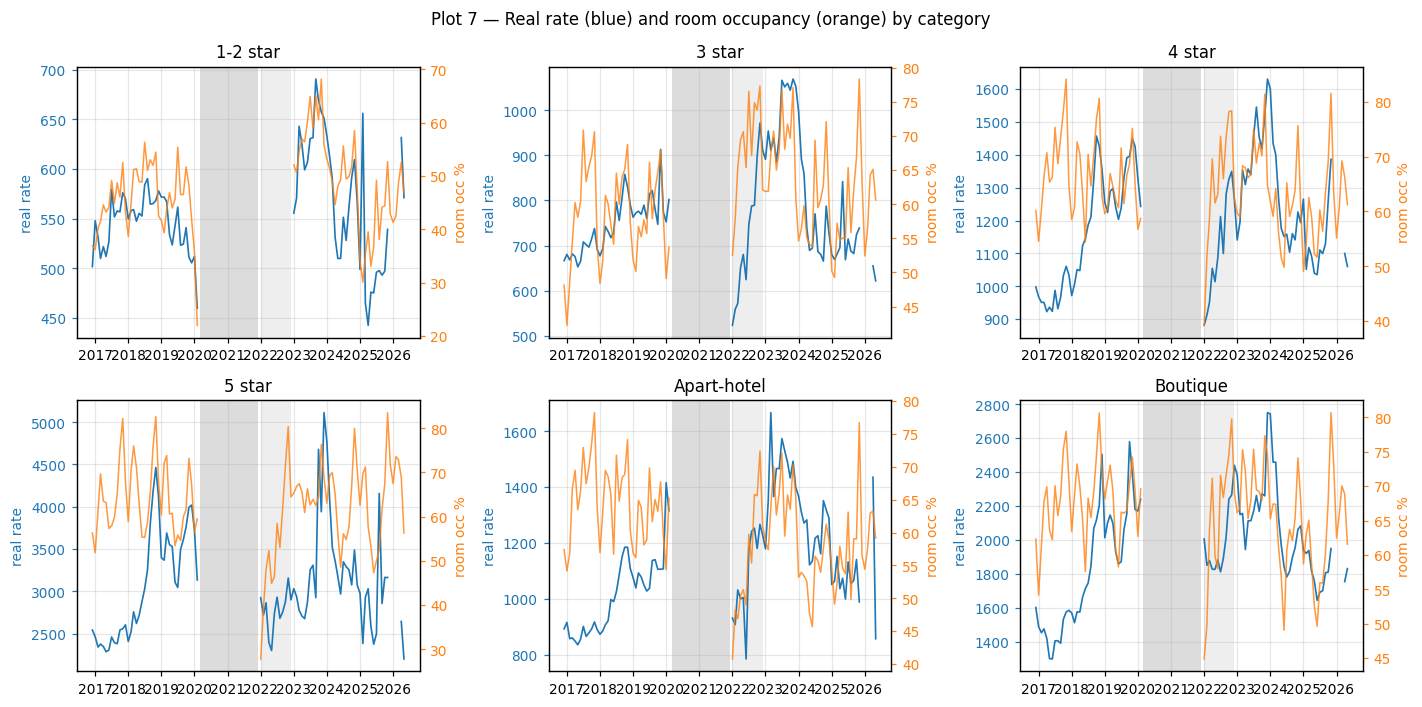

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, cat in zip(axes.ravel(), MODEL):
    s = W[W.hotel_category == cat].sort_values("date")
    ax.plot(s.date, s.real_rate_gba, color="tab:blue", lw=1.1)
    ax.set_ylabel("real rate", color="tab:blue"); ax.tick_params(axis="y", colors="tab:blue")
    a2 = ax.twinx()
    a2.plot(s.date, s.room_occupancy, color="tab:orange", lw=1.0, alpha=.8)
    a2.set_ylabel("room occ %", color="tab:orange"); a2.tick_params(axis="y", colors="tab:orange")
    a2.grid(False)
    shade_covid(ax)
    ax.set_title(LAB[cat])
fig.suptitle("Plot 7 — Real rate (blue) and room occupancy (orange) by category")
save(fig, "04_plot7_price_and_occupancy.png")

## Plot 8 · Traveller volumes over time

  [04_descriptive] figure                 04_plot8_travelers.png                     


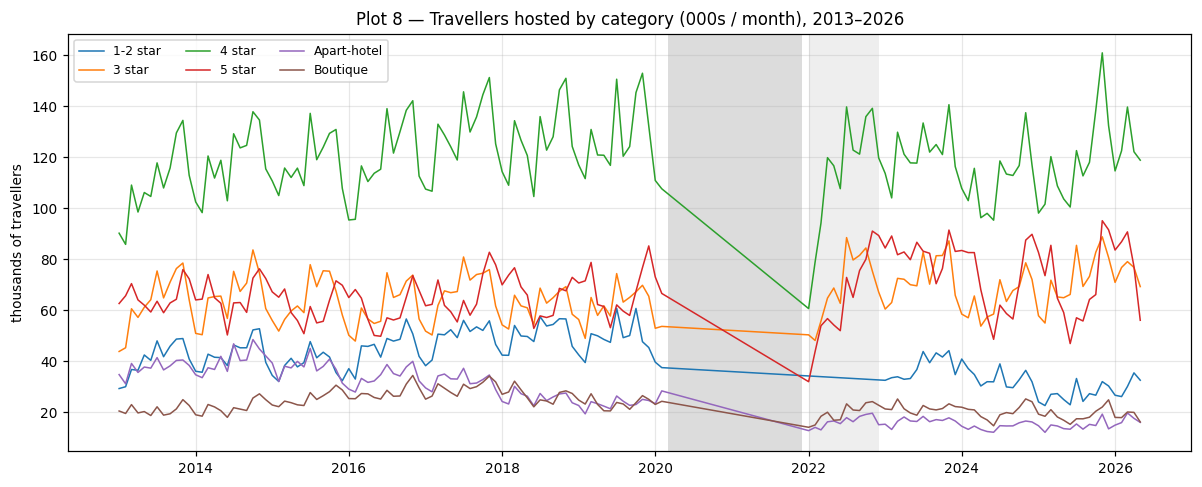

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cat in C.CORE_CATEGORIES + ["apart", "boutique"]:
    s = df[(df.hotel_category == cat) & df.travelers.notna()].sort_values("date")
    ax.plot(s.date, s.travelers / 1e3, lw=1.0, label=LAB[cat])
shade_covid(ax)
ax.set_title("Plot 8 — Travellers hosted by category (000s / month), 2013–2026")
ax.set_ylabel("thousands of travellers")
ax.legend(ncol=3, fontsize=8)
save(fig, "04_plot8_travelers.png")

## Plot 9 · Available capacity over time (quarterly snapshots)

  [04_descriptive] figure                 04_plot9_capacity.png                      


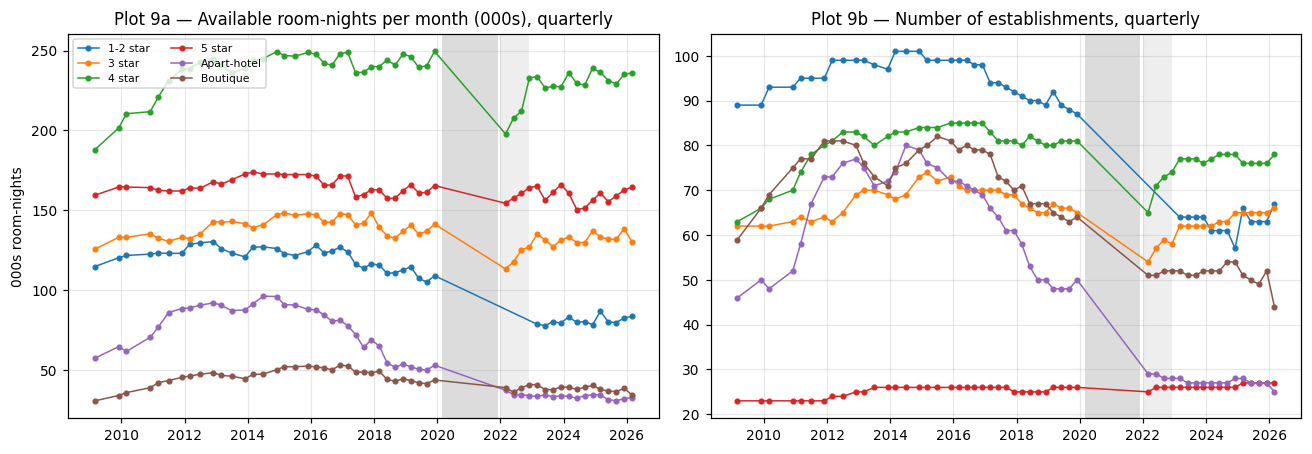

In [10]:
capq = pd.read_parquet(C.P_CAPACITY_Q)
cq = capq[capq.source_taxonomy == "ehoba"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for cat in MODEL:
    s = cq[cq.hotel_category == cat].sort_values("date")
    ax[0].plot(s.date, s.available_room_nights / 1e3, marker="o", ms=3, lw=1, label=LAB[cat])
    s2 = cq[cq.hotel_category == cat].sort_values("date")
    ax[1].plot(s2.date, s2.establishments, marker="o", ms=3, lw=1)
for a in ax:
    shade_covid(a)
ax[0].set_title("Plot 9a — Available room-nights per month (000s), quarterly")
ax[0].set_ylabel("000s room-nights"); ax[0].legend(ncol=2, fontsize=7)
ax[1].set_title("Plot 9b — Number of establishments, quarterly")
save(fig, "04_plot9_capacity.png")

## Table 1 — descriptive statistics by category (in-window, COVID-hole excluded)

In [11]:
T = W[(W.covid_hole == 0) & W.hotel_category.isin(MODEL)]
rows = []
for cat, s in T.groupby("hotel_category"):
    rate_mom = np.exp(s.dln_average_rate) - 1
    faster = s.dln_average_rate > np.log1p(s.infl_mom_gba / 100)
    rows.append(dict(
        hotel_category=cat, label=LAB[cat], n_months=len(s),
        nominal_rate_mean=s.average_rate.mean(),
        real_rate_gba_mean=s.real_rate_gba.mean(), real_rate_gba_sd=s.real_rate_gba.std(),
        real_rate_cagr_pct=((s.sort_values("date").real_rate_gba.iloc[-1] /
                             s.sort_values("date").real_rate_gba.iloc[0])
                            ** (12 / len(s)) - 1) * 100,
        room_occ_mean=s.room_occupancy.mean(), room_occ_sd=s.room_occupancy.std(),
        bed_occ_mean=s.bed_occupancy.mean(),
        rate_mom_mean_pct=rate_mom.mean() * 100, rate_mom_sd_pct=rate_mom.std() * 100,
        cpi_mom_mean_pct=s.infl_mom_gba.mean(),
        share_months_rate_gt_cpi=faster.mean(),
        share_months_rate_up=(s.dln_average_rate > 0).mean(),
    ))
tab1 = pd.DataFrame(rows).set_index("hotel_category").round(3)
tab1.to_csv(C.OUT_TAB / "table1_descriptives.csv")
LOG.log("write", "table1_descriptives.csv", len(tab1))
LOG.flush()
tab1

  [04_descriptive] write                  table1_descriptives.csv                 6  


,label,n_months,nominal_rate_mean,real_rate_gba_mean,real_rate_gba_sd,real_rate_cagr_pct,room_occ_mean,room_occ_sd,bed_occ_mean,rate_mom_mean_pct,rate_mom_sd_pct,cpi_mom_mean_pct,share_months_rate_gt_cpi,share_months_rate_up
hotel_category,,,,,,,,,,,,,,
apart,Apart-hotel,92,33256.333,1124.324,198.725,-0.528,60.753,7.527,42.312,5.612,11.808,4.631,0.489,0.772
boutique,Boutique,92,55328.781,1934.081,318.239,1.759,66.344,7.066,54.425,5.335,8.639,4.631,0.543,0.739
stars_1_2,1-2 star,92,17645.014,558.192,52.646,1.707,47.508,8.079,40.716,4.406,7.944,4.631,0.402,0.641
stars_3,3 star,92,21134.575,769.722,122.453,-0.904,61.374,7.740,48.943,5.670,8.881,4.631,0.467,0.707
stars_4,4 star,92,34137.888,1194.647,176.731,0.793,64.717,8.116,51.708,5.552,7.957,4.631,0.478,0.728
stars_5,5 star,92,87870.194,3085.302,618.710,-1.868,62.911,9.619,45.675,5.627,15.492,4.631,0.446,0.609
